# 03 EDA and Statistical Analysis

This notebook reviews customer characteristics, target imbalance, product relationships, and business patterns before model training.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

PROJECT_ROOT

WindowsPath('d:/Banking and Finance/Projects/canadian-bank-loan-propensity-mlops-deployment')

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from src.config import CLEANED_DATA_PATH, TARGET_COL
from src.data_preprocessing import get_data_quality_summary

data = pd.read_csv(CLEANED_DATA_PATH)

print(data.shape)
display(data.head())

(4980, 14)


,ID,Age,CustomerSince,HighestSpend,ZipCode,HiddenScore,MonthlyAverageSpend,Level,Mortgage,Security,FixedDepositAccount,InternetBanking,CreditCard,LoanOnCard
0,10,34,9,180,93023,1,8.9,3,0,0,0,0,0,1
1,11,65,39,105,94710,4,2.4,3,0,0,0,0,0,0
2,12,29,5,45,90277,3,0.1,2,0,0,0,1,0,0
3,13,48,23,114,93106,2,3.8,3,0,1,0,0,0,0
4,14,59,32,40,94920,4,2.5,2,0,0,0,1,0,0


In [3]:
target_distribution = (
    data[TARGET_COL]
    .value_counts(normalize=True)
    .rename_axis("LoanOnCard")
    .reset_index(name="proportion")
)
target_distribution["count"] = data[TARGET_COL].value_counts().values
display(target_distribution)

,LoanOnCard,proportion,count
0,0,0.903614,4500
1,1,0.096386,480


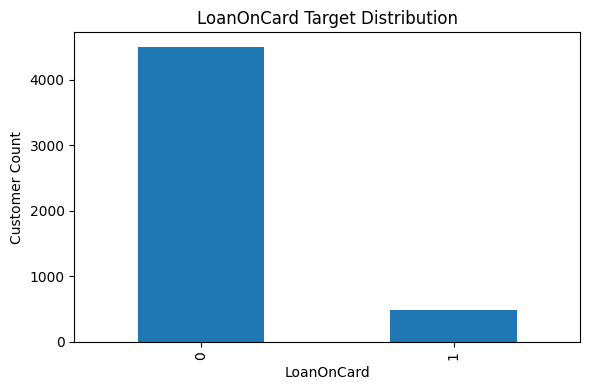

In [4]:
plt.figure(figsize=(6, 4))
data[TARGET_COL].value_counts().sort_index().plot(kind="bar")
plt.title("LoanOnCard Target Distribution")
plt.xlabel("LoanOnCard")
plt.ylabel("Customer Count")
plt.tight_layout()
plt.show()

## Numeric Feature Review

In [5]:
numeric_cols = ["Age", "CustomerSince", "HighestSpend", "MonthlyAverageSpend", "Mortgage"]
display(data[numeric_cols].describe().T)

,count,mean,std,min,25%,50%,75%,max
Age,4980.0,45.352610,11.464212,23.0,35.0,45.0,55.000,67.0
CustomerSince,4980.0,20.132530,11.441482,0.0,10.0,20.0,30.000,43.0
HighestSpend,4980.0,73.852410,46.070090,8.0,39.0,64.0,98.000,224.0
MonthlyAverageSpend,4980.0,1.939536,1.750006,0.0,0.7,1.5,2.525,10.0
Mortgage,4980.0,56.589759,101.836758,0.0,0.0,0.0,101.000,635.0


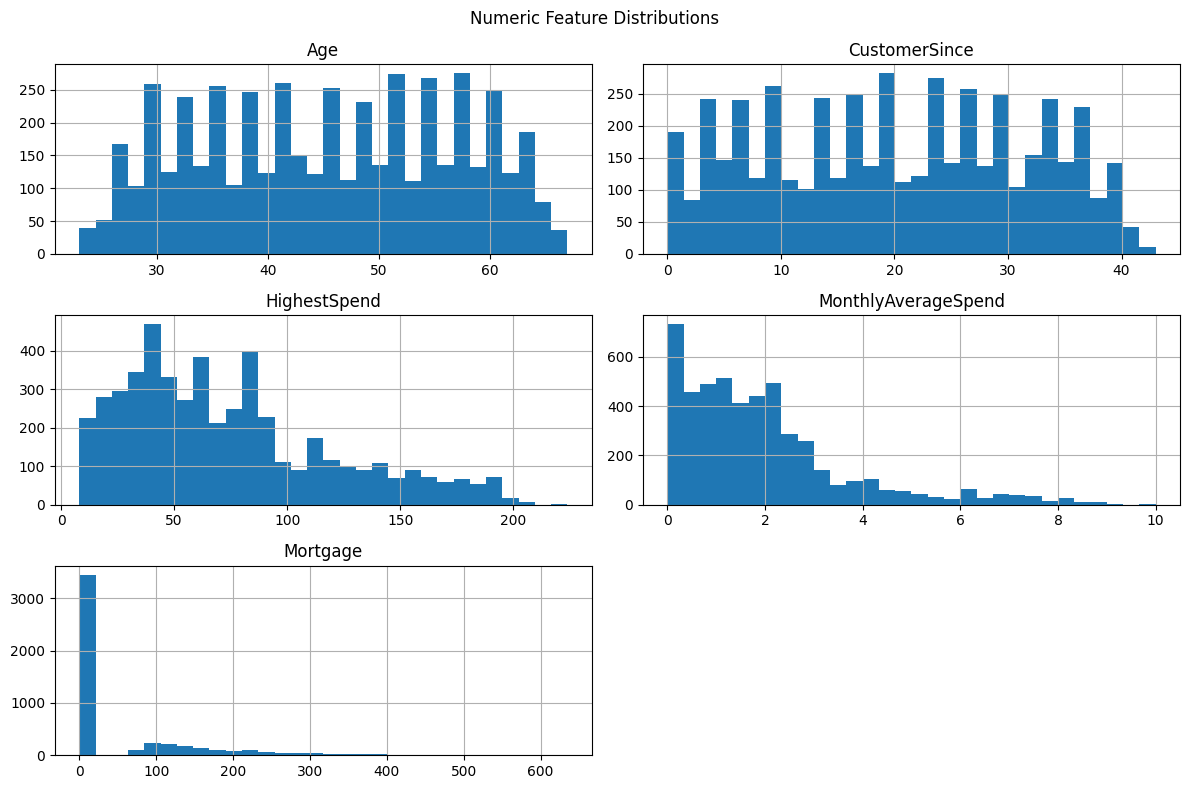

In [6]:
data[numeric_cols].hist(figsize=(12, 8), bins=30)
plt.suptitle("Numeric Feature Distributions")
plt.tight_layout()
plt.show()

## Loan Propensity by Customer and Product Attributes

In [7]:
categorical_review = []

for column in ["Level", "HiddenScore", "Security", "FixedDepositAccount", "InternetBanking", "CreditCard"]:
    grouped = (
        data.groupby(column)[TARGET_COL]
        .agg(["count", "mean"])
        .reset_index()
        .rename(columns={"mean": "loan_rate"})
    )
    grouped["feature"] = column
    categorical_review.append(grouped)

display(pd.concat(categorical_review, ignore_index=True))

,Level,count,loan_rate,feature,HiddenScore,Security,FixedDepositAccount,InternetBanking,CreditCard
0,1.0,2089,0.044519,Level,NaN,NaN,NaN,NaN,NaN
1,2.0,1395,0.130466,Level,NaN,NaN,NaN,NaN,NaN
2,3.0,1496,0.137032,Level,NaN,NaN,NaN,NaN,NaN
3,NaN,1466,0.072988,HiddenScore,1.0,NaN,NaN,NaN,NaN
4,NaN,1293,0.081980,HiddenScore,2.0,NaN,NaN,NaN,NaN
5,NaN,1006,0.132207,HiddenScore,3.0,NaN,NaN,NaN,NaN
6,NaN,1215,0.110288,HiddenScore,4.0,NaN,NaN,NaN,NaN
7,NaN,4460,0.094170,Security,NaN,0.0,NaN,NaN,NaN
8,NaN,520,0.115385,Security,NaN,1.0,NaN,NaN,NaN
9,NaN,4678,0.072681,FixedDepositAccount,NaN,NaN,0.0,NaN,NaN


In [8]:
corr = data[["Age", "CustomerSince", "HighestSpend", "MonthlyAverageSpend", "Mortgage", TARGET_COL]].corr()
display(corr)

,Age,CustomerSince,HighestSpend,MonthlyAverageSpend,Mortgage,LoanOnCard
Age,1.000000,0.994190,-0.054951,-0.051896,-0.013272,-0.008147
CustomerSince,0.994190,1.000000,-0.046262,-0.049756,-0.011632,-0.008244
HighestSpend,-0.054951,-0.046262,1.000000,0.646109,0.207236,0.502626
MonthlyAverageSpend,-0.051896,-0.049756,0.646109,1.000000,0.110275,0.366912
Mortgage,-0.013272,-0.011632,0.207236,0.110275,1.000000,0.141947
LoanOnCard,-0.008147,-0.008244,0.502626,0.366912,0.141947,1.000000


## EDA Takeaways

- The target is imbalanced, which means accuracy alone is not enough.
- Product holdings, customer value indicators, spending behaviour, and tenure should be evaluated as potential drivers.
- The modeling phase should focus on precision, recall, F1 score, ROC-AUC, and false positive/false negative analysis.